# Setup

In [1]:
from data.cleaning import read_csv
from core import Config
import pandas as pd

config = Config()
TARGET = config.TARGET
MISSINGNESS_THRESH = 50
SECTOR: int | None = None
LOG = True
WINSORIZED = True
NEGATIVE_TARGET = False
EARLY_DROP = False
imputed_file_str = f"imputed_thresh_{MISSINGNESS_THRESH}"
basis_file_str = f"basis_thresh_{MISSINGNESS_THRESH}"
verification_mode = True
if WINSORIZED:
    imputed_file_str += "_win"
    basis_file_str += "_win"
if LOG:
    imputed_file_str += "_log"
    basis_file_str += "_log"
if EARLY_DROP:
    imputed_file_str += "_early_drop"
    basis_file_str += "_early_drop"
if SECTOR:
    imputed_file_str += f"_sector_{SECTOR}"
    basis_file_str += f"_sector_{SECTOR}"
if verification_mode:
    imputed_file_str += "_verification"
    basis_file_str += "_verification"
# -r = redundancies removed
imputed_file_str += "-r.csv"
basis_file_str += "-r.csv"
save_file = config.training_dir / imputed_file_str

static_df: pd.DataFrame = read_csv(
    config.selected_dir / "selected_static.csv",
    config.selected_dir / "selected_static_dtypes.csv",
    [0]
)

historic_df: pd.DataFrame = read_csv(
    config.selected_dir / "selected_historic.csv",
    config.selected_dir / "selected_historic_dtypes.csv",
    [0]
)

static_ver: pd.DataFrame = read_csv(
    config.verification_dir / "verification_static.csv",
    config.verification_dir / "verification_static_dtypes.csv",
    [0]
)

historic_ver: pd.DataFrame = read_csv(
    config.verification_dir / "verification_historic.csv",
    config.verification_dir / "verification_historic_dtypes.csv",
    [0]
)

## Convert and Remove Features with constant values

In [2]:
# Filter and convert historic dataframe
# Detect columns with only boolean-like strings and convert dtype to boolean
def is_bool_string_col(series):
    bool_strings = [{'true', 'false'}, {'True', 'False'}, {'yes', 'no'}, {'Yes', 'No'}, {'1', '0'}]
    values = set(series.dropna().unique())
    return any(values <= s for s in bool_strings)


def transform_bool_strings(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    for col in df.select_dtypes(include=['object', 'string']):
        if is_bool_string_col(df[col]):
            df[col] = df[col].replace(
                {'true': True, 'True': True, 'yes': True, 'Yes': True, '1': True,
                 'false': False, 'False': False, 'no': False, 'No': False, '0': False}).astype('boolean')
            df[col] = df[col].astype('boolean')
    return df


def convert_to_categorical(dataframe: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = dataframe.copy()
    for col in columns:
        df[col] = df[col].astype('category')
    return df


# remove columns with only one unique (non‑NaN) value
def remove_constant_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    nunique = df.nunique(dropna=True)
    cols_to_drop = nunique[nunique == 1].index
    return df.drop(columns=cols_to_drop)


historic_df = transform_bool_strings(historic_df)
historic_ver = transform_bool_strings(historic_ver)

# Join static and historic dataframe to have GICS Sector Codes in the dataframe
all_df = historic_df.merge(
    static_df,
    on='Instrument',
    how='left'
)

all_ver = historic_ver.merge(
    static_ver,
    on='Instrument',
    how='left'
)

all_ver_df = pd.concat([all_df, all_ver], axis=0, ignore_index=True)

if verification_mode:
    all_df = all_ver_df.copy()

all_df = convert_to_categorical(all_df,
                                ['TR.GICSIndustryCode', 'TR.GICSIndustryGroupCode', 'TR.GICSSectorCode', 'Date'])
all_df = remove_constant_columns(all_df)

In [3]:
# handling outlier based on analysis at bottom of Notebook
mask = (all_df['Instrument'] == 'ISS.CO') & (all_df['Date'].astype(int) == 2019) & (
        all_df['TR.UpstreamScope3PurchasedGoodsAndServices'] == 711_751_000_000.0)

all_df.loc[mask, 'TR.UpstreamScope3PurchasedGoodsAndServices'] = 711_751_000_000.0 / 1_000_000

In [4]:
# remove all sectors except one for sector-specific training dataset
if SECTOR:
    all_df = all_df[all_df['TR.GICSSectorCode'] == SECTOR]

## Manuall Filter

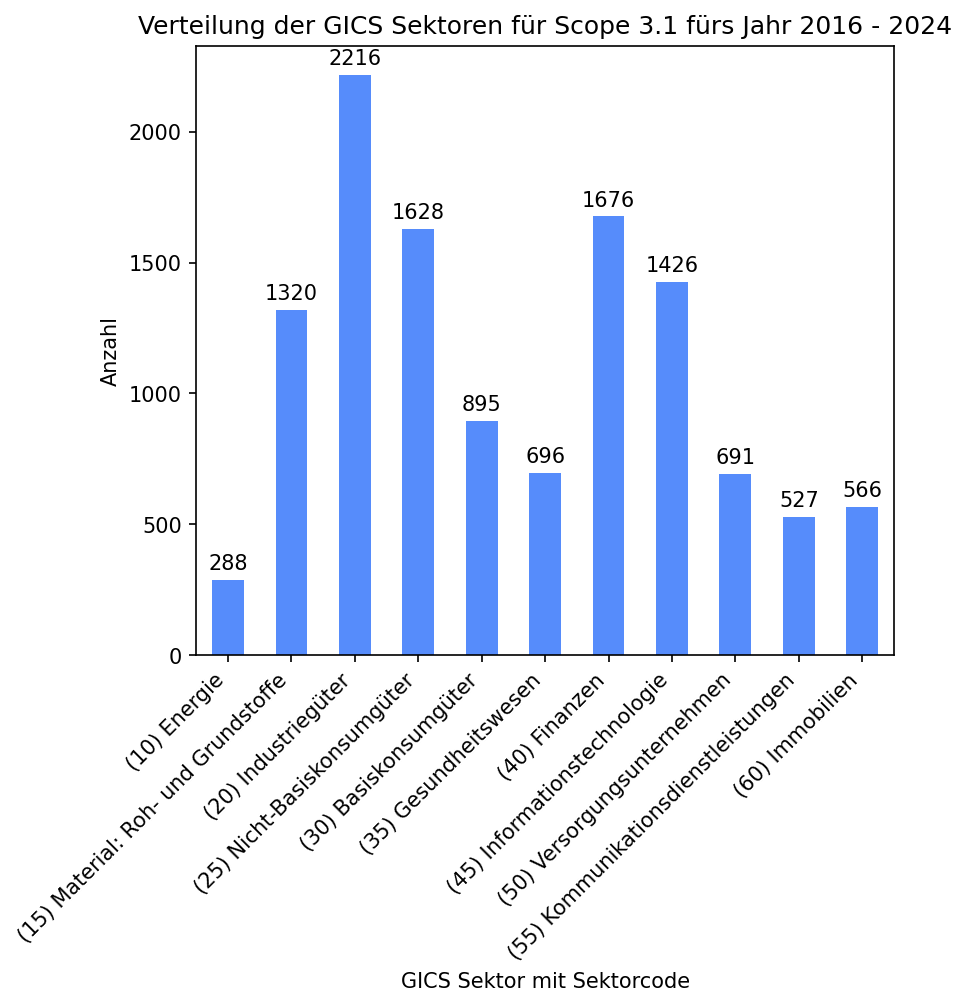

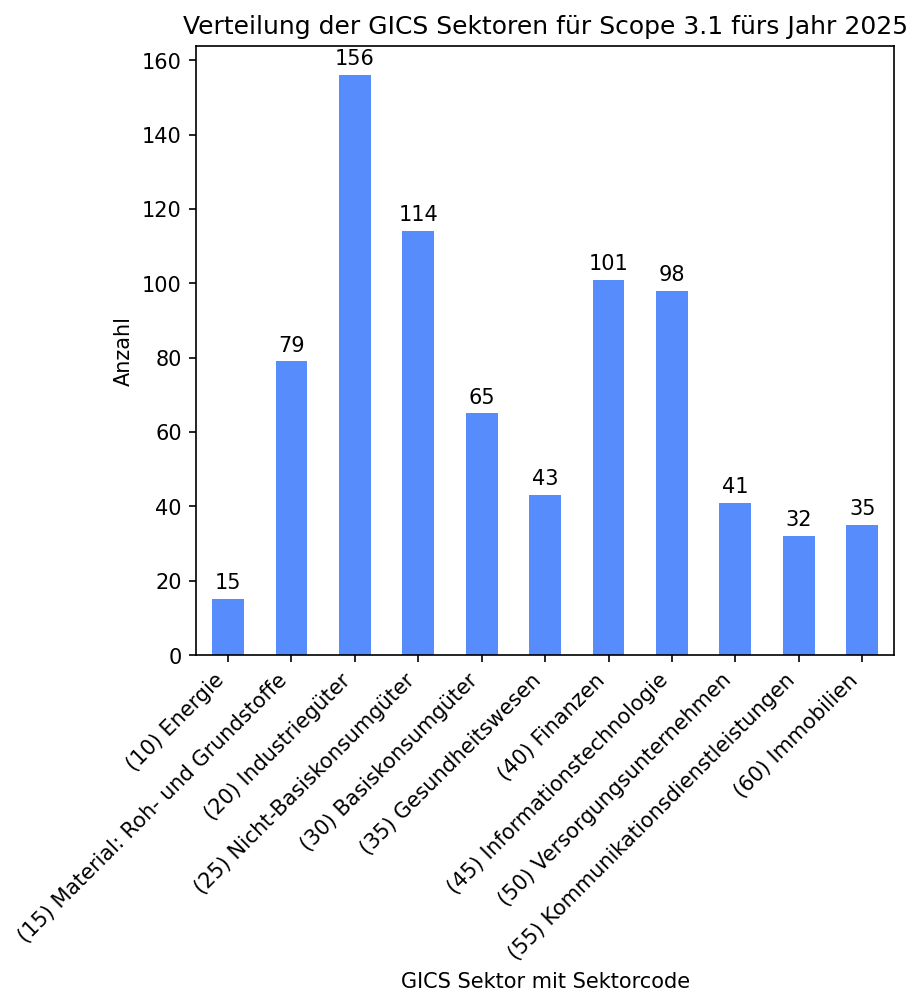

In [22]:
# Plot how the data is distributed the TR.GICSIndustryGroupCodes & TR.GICSSectorCodes
def plot_industry_code_distribution(df: pd.DataFrame, industry_code_col: str, title: str) -> None:
    # replace code with word
    df = df.copy()
    df[industry_code_col] = df[industry_code_col].astype(str)
    codes: dict[str, str] = {
        "10": "(10) Energie",
        "15": "(15) Material: Roh- und Grundstoffe",
        "20": "(20) Industriegüter",
        "25": "(25) Nicht-Basiskonsumgüter",
        "30": "(30) Basiskonsumgüter",
        "35": "(35) Gesundheitswesen",
        "40": "(40) Finanzen",
        "45": "(45) Informationstechnologie",
        "50": "(50) Versorgungsunternehmen",
        "55": "(55) Kommunikationsdienstleistungen",
        "60": "(60) Immobilien",
    }
    df[industry_code_col] = df[industry_code_col].replace(codes)
    industry_code_counts = df[industry_code_col].value_counts().sort_index()
    plt.figure(figsize=(6, 7), dpi=150)
    ax = industry_code_counts.plot(kind="bar")
    ax.set_ylabel("Anzahl")
    ax.set_title(f"Verteilung der GICS Sektoren für Scope 3.1 {title}")
    ax.set_xlabel("GICS Sektor mit Sektorcode")
    for bar_column in ax.containers:
        ax.bar_label(bar_column, labels=industry_code_counts, padding=3)
    plt.xticks(rotation=45, ha="right")
    plt.subplots_adjust(bottom=0.3)
    plt.show()


#plot_industry_code_distribution(all_df, "TR.GICSIndustryGroupCode")
all_df.dropna(subset=[TARGET], inplace=True)
plot_industry_code_distribution(all_df, "TR.GICSSectorCode", "fürs Jahr 2016 - 2024")
all_ver.dropna(subset=[TARGET], inplace=True)
plot_industry_code_distribution(all_ver, "TR.GICSSectorCode", "fürs Jahr 2025")

# Data is distributed very heterogen. In IndustryGroup the fewest category has around 300 companies, whereas in Sector over 500.

In [ ]:
# Manually remove redundant data
all_df.drop(
    [
        'TR.HeadquartersCountry',
        'TR.BusinessSector',
        'TR.TRBCActivity',
        'TR.TRBCIndustry',
        'TR.NAICSSector',
        'TR.NACEClassification',
        'TR.GICSSubIndustryCode',
        'TR.GICSIndustryCode',
        'TR.GICSIndustryGroupCode',
    ], axis=1, inplace=True)

"""
TR.COGSActValue & TR.F.COGSTot by definition, are relatively similar and at first glance seem to behave the same. TR.F.COGSTot has lower missingness.
TR.GPMActValue & TR.F.GrossProfMarg by definition, are relatively similar. TR.F.GrossProfMarg has lower missingness.
TR.GrossIncomeActValue & TR.F.GrossProfIndPropTot by definition, are relatively similar. TR.F.GrossProfIndPropTot has lower missingness.
TR.CO2EquivalentEmissionIndirectScope2Locationbased has almost half of its values NA. And those values both report are almost the same.
TR.HeadquartersCountry & TR.HQCountryCode are basically the same. More interesting would be in which countries a company is operating.
TR.GICSIndustryCode is the main company differentiator. All others can be looked into if time allows.
"""

# Create labeled DataFrame with row filtered emtpy Scope3.1 and zero value
labeled_df: pd.DataFrame = all_df.copy()
if EARLY_DROP:
    labeled_df[TARGET] = labeled_df[TARGET].dropna()

labeled_df = labeled_df[labeled_df[TARGET] != 0]
#labeled_df = labeled_df[labeled_df[TARGET] < 100_000_000]

# Analyse Scope 3.1 and Winzorise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# all positive numbered features are heavily skewed with a large tail to the right, because few very large companies tend to have more of everything
pos_features: list[str] = [
    'TR.WasteRecycledTotal',
    'TR.TotalAssetsActual',
    'TR.TotalRenewableEnergy',
    'TR.InventoryActValue',
    'TR.F.TotLiab',
    'TR.CO2EquivalentEmissionIndirectScope2Locationbased',
    'TR.CO2IndirectScope2',
    'TR.SGandAExpActual',
    'TR.WasteTotal',
    'TR.NumberofEmployees',
    'TR.EnergyUseTotal',
    'TR.CurrentAssetsActValue',
    'TR.CapexActValue',
    'TR.CurrentLiabilitiesActValue',
    'TR.CO2DirectScope1',
    'TR.F.PPEGrossTot',
    'TR.RenewEnergyProduced',
    'TR.UpstreamScope3PurchasedGoodsAndServices',
    'TR.F.IntangGrossTot',
    'TR.F.InvntTurnover',
    'TR.F.COGSTot',
    'TR.RenewEnergyPurchased',
    'TR.EnergyUseIndirect'
]
neg_features: list[str] = [
    'TR.TotalDebtActValue',
    'TR.GoodwillActValue',
    'TR.F.OpExpn',
    'TR.F.GrossProfMarg',
    'TR.F.GrossProfIndPropTot',
    'TR.GPMActValue',
    'TR.NWCActValue',
    'TR.GrossIncomeActValue',
    'TR.F.AcctRcvblTurnover'
]

if NEGATIVE_TARGET:
    TARGET = neg_features[8]

target_values: pd.Series = labeled_df[TARGET]
fig, (ax_raw, ax_log) = plt.subplots(2, 1, figsize=(6, 6))

# Raw
sns.histplot(target_values, kde=True, bins=30, ax=ax_raw)
ax_raw.set_title(f"{TARGET} (raw)")
ax_raw.set_xlabel(TARGET)
ax_raw.set_ylabel("Frequency")

# Result is heavily skewed to the right
# log target value for normal distribution
# sign(x) * log(abs(x)) for negative values column
if NEGATIVE_TARGET:
    target_values_log = target_values.transform(lambda x: np.sign(x) * np.log(np.abs(x)))
else:
    target_values_log = pd.Series(np.log(target_values))

# log
sns.histplot(target_values_log, kde=True, bins=30, ax=ax_log)
ax_log.set_title(f"{TARGET} (log)")
ax_log.set_xlabel(f"log({TARGET})")
ax_log.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Winsorize

In [ ]:
# Winsorize first and 99th quantile of column Scope 3.1
def winsorize_series(s: pd.Series, q_low=0.01, q_high=0.99) -> pd.Series:
    # s: 1D Series
    threshold_low, threshold_high = s.quantile([q_low, q_high])
    return s.clip(lower=threshold_low, upper=threshold_high)


winsorized: pd.Series = winsorize_series(target_values)
winsorized_log: pd.Series = winsorize_series(target_values_log)

fig, (ax_raw, ax_log) = plt.subplots(2, 1, figsize=(6, 6))

# Raw
sns.histplot(winsorized, kde=True, bins=30, ax=ax_raw)
ax_raw.set_title(f"Winsorized distribution of {TARGET} (raw)")
ax_raw.set_xlabel(TARGET)
ax_raw.set_ylabel("Frequency")

# log
sns.histplot(winsorized_log, kde=True, bins=30, ax=ax_log)
ax_log.set_title(f"Winsorized distribution of {TARGET} (log)")
ax_log.set_xlabel(f"log({TARGET})")
ax_log.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# use Winsorize series to reduce labeled dataset
target_df = labeled_df.copy()
if LOG & WINSORIZED:
    target_df[TARGET] = winsorized_log
elif LOG:
    target_df[TARGET] = target_values_log
elif WINSORIZED:
    target_df[TARGET] = winsorized

# drop Scope 3.1 values over
#target_df = target_df[labeled_df[TARGET] < 1_000_000]

In [ ]:
# free up variables
del target_values, target_values_log, winsorized, winsorized_log, pos_features
del fig, ax_raw, ax_log, sns, plt
# TODO OPTIONAL winsorize all other features

# Missingness

In [ ]:
# calculate missingness untouched labeled dataframe
# reduce on temporary TARGET variable dropna()
def over_missingness(series: pd.Series, threshold=MISSINGNESS_THRESH) -> list:
    candidates: list[str] = series[series > threshold].index.tolist()
    return candidates


temp_df: pd.DataFrame = target_df.copy()
temp_df.dropna(subset=[TARGET], inplace=True)
missing_counts: pd.Series = temp_df.isna().sum()
percent_missing_sum_method: pd.Series = (missing_counts / temp_df.shape[0]) * 100

lm_df: pd.DataFrame = pd.DataFrame()
# universal low missingness DataFrame across sectors
if verification_mode and SECTOR:
    print(f"Verification + Sector: {SECTOR}")
    lm_df = temp_df[['Instrument', 'Date', 'TR.TotalAssetsActual', 'TR.F.PPENetTot',
                     'TR.CO2IndirectScope2', 'TR.F.OpExpn', 'TR.NumberofEmployees',
                     'TR.CO2DirectScope1', 'TR.UpstreamScope3PurchasedGoodsAndServices',
                     'TR.TakebackRecyclingInitiatives', 'TR.RenewEnergyUse',
                     'TR.PolicyEmissions', 'TR.PolicyEnergyEfficiency',
                     'TR.PolicyEnvSupplyChain', 'TR.PolicyFairTrade',
                     'TR.PolicySustainablePackaging', 'TR.GICSSectorCode',
                     'TR.HQCountryCode']]
else:
    lm_df = temp_df.drop(over_missingness(percent_missing_sum_method), axis=1)

del missing_counts, percent_missing_sum_method, temp_df

In [ ]:
# Basis Model
lm_df.to_csv(config.training_dir / basis_file_str)
print(f"Basis Model: {lm_df.shape[0]} rows, {lm_df.shape[1]} columns")

# reduce feature set to the top 9 shap features
if MISSINGNESS_THRESH >= 90:
    lm_df[[
        "TR.F.OpExpn",
        "TR.GICSSectorCode",
        "TR.InventoryActValue",
        "TR.HQCountryCode",
        "TR.CO2IndirectScope2",
        "TR.CO2DirectScope1",
        "TR.WasteRecycledTotal",
        "TR.F.GrossProfMarg",
        "TR.WasteTotal",
        "TR.GICSSectorCode",
        "TR.UpstreamScope3PurchasedGoodsAndServices",
        "Instrument",
    ]].to_csv(config.training_dir / f"top9_global_shap_{basis_file_str}")
    lm_df[[
        "TR.F.OpExpn",
        "TR.CO2DirectScope1",
        "TR.CO2IndirectScope2",
        "TR.NumberofEmployees",
        "TR.InventoryActValue",
        "TR.HQCountryCode",
        "TR.F.PPENetTot",
        "TR.F.GrossProfIndPropTot",
        "TR.CurrentAssetsActValue",
        "TR.UpstreamScope3PurchasedGoodsAndServices",
        "TR.GICSSectorCode",
        "Instrument",
    ]].to_csv(config.training_dir / f"top9_counted_shap_{basis_file_str}")
    lm_df[[
        "TR.F.OpExpn",
        "TR.CO2DirectScope1",
        "TR.CO2IndirectScope2",
        "TR.NumberofEmployees",
        "TR.InventoryActValue",
        "TR.HQCountryCode",
        "TR.F.PPENetTot",
        "TR.F.GrossProfIndPropTot",
        "TR.CurrentAssetsActValue",
        "TR.EnergyUseTotal",
        "TR.WasteRecycledTotal",
        "TR.CurrentLiabilitiesActValue",
        "TR.TotalAssetsActual",
        "TR.WasteTotal",
        "TR.CapexActValue",
        "TR.F.GrossProfMarg",
        "TR.GrossIncomeActValue",
        "TR.GoodwillActValue",
        "TR.TotalDebtActValue",
        "TR.PolicySustainablePackaging",
        "TR.GICSSectorCode",
        "TR.RenewEnergyProduced",
        "TR.SGandAExpActual",
        "TR.F.AcctRcvblTurnover",
        "TR.TakebackRecyclingInitiatives",
        "TR.UpstreamScope3PurchasedGoodsAndServices",
        "TR.GICSSectorCode",
        "Instrument",
    ]].to_csv(config.training_dir / f"all_shap_features_{basis_file_str}")

## Redundancies

In [ ]:
if "TR.CO2EquivalentEmissionIndirectScope2Locationbased" in lm_df.columns:

    col_a = "TR.CO2EquivalentEmissionIndirectScope2Locationbased"
    col_b = "TR.CO2IndirectScope2"

    # Fill NA with 0 and compare elementwise
    same_mask = (
            (lm_df[col_a] == lm_df[col_b]) |
            (lm_df[col_a].isna() & lm_df[col_b].isna())
    )
    same_count = same_mask.sum()

    print(f"Same count: {same_count}")
    print(f"Value count: {lm_df[col_a].notna().sum()}")
    # TR.CO2EquivalentEmissionIndirectScope2Locationbased has almost half of its values NA. And those values both report are almost the same.
    # Keeping TR.CO2IndirectScope2, cause it has lower missingness.

    # low redundancies DataFrame
    lr_df = lm_df.drop(col_a, axis=1)

    del col_a, col_b, same_mask, same_count, lm_df
else:
    lr_df = lm_df

# Imputation
Imputation of categorical data isn't needed because remaining features (only TR.GICSSectorCode & TR.HQCountryCode) are complete.

In [ ]:
from data.imputation import calculate_mode, calculate_median

imputed_df: pd.DataFrame = calculate_median(lr_df)
imputed_df = calculate_mode(imputed_df)
if EARLY_DROP:
    imputed_df[TARGET] = imputed_df[TARGET].dropna()
if imputed_df.isna().sum().sum() > 0:
    print(f"Imputation: {imputed_df.isna().sum().sum()} values are not Zero!!!")

# VIF Analysis

In [ ]:
# convert all boolean columns in pandas dataframe to int
bool_cols = imputed_df.select_dtypes(include=['boolean']).columns
imputed_df[bool_cols] = imputed_df[bool_cols].astype('int')

del bool_cols

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

if not SECTOR:
    vif_data = pd.DataFrame()
    num_frame = imputed_df.select_dtypes(include=['number']).copy()
    num_frame.drop(columns=['TR.UpstreamScope3PurchasedGoodsAndServices'], inplace=True)
    x = num_frame.to_numpy(dtype=np.float64)
    vif_data["feature"] = num_frame.columns
    vif_data["VIF"] = [variance_inflation_factor(x, i) for i in range(x.shape[1])]
    vif_data = vif_data.sort_values(by="VIF")
    del x, num_frame

In [ ]:
if not verification_mode and SECTOR:
    imputed_df[['TR.RevenueActValue', 'TR.F.OpExpn']].corr()

In [ ]:
"""
TR.F.PPEGrossTot, TR.F.PPEAccumDeprTot & TR.F.PPENetTot correlate due to their dependence on company property. Gross − Accumulated Depreciation = Net. Keeping TR.F.PPENetTot, as it combines the two other values. TR.F.PPEGrossTot could also be interesting, cause it is the easiest variable to report.

TR.COGSActValue & TR.F.COGSTot highly correlate almost in the same way. Direct cost to produce vs. all factored cost to produce. Keeping TR.COGSActValue because the direct costs seem easier to report.

TR.F.TotCap, TR.NetProfitActValue, TR.EBITActValue & TR.EBITDAActValue correlate. Features report how much financial success a company has. Revenue before or after taxes, the capital, etc. Keeping TR.EBITDAActValue, no reason.

TR.TotalAssetsActual & TR.F.TotLiab highly correlate. Keeping TR.TotalAssetsActual cause it just reports what the company owns, excluding dept, etc.

TR.F.OpExpn & TR.OperatingExpActual moderately correlate (0,76). Keeping TR.F.OpExpn, because it is easier to report due to not having to cleanup the data.

TR.EBITDAActValue is the result of TR.RevenueActValue - TR.COGSActValue - TR.F.OpExpn. Company Result before Taxes ≈ Revenue - Direct Costs - Operating Expenses. Remove TR.EBITDAActValue.

TR.RevenueActValue & TR.COGSActValue highly correlate (0.91). Keeping TR.RevenueActValue, because it has lower missingness.

TR.RevenueActValue & TR.F.OpExpn highly correlate (0.97). Keeping TR.F.OpExpn, because it has lower missingness.
"""

variance_columns: set[str] = {
    'TR.F.PPEGrossTot',
    'TR.F.PPEAccumDeprTot',
    'TR.F.COGSTot',
    'TR.EBITActValue',
    'TR.NetProfitActValue',
    'TR.F.TotCap',
    'TR.EBITDAActValue',
    'TR.OperatingExpActual',
    'TR.F.TotLiab',
    'TR.RevenueActValue',
    'TR.COGSActValue'
}

imputed_df.drop(columns=set(imputed_df.columns) & variance_columns, inplace=True)

In [ ]:
# save DataFrame to csv
imputed_df.to_csv(save_file)
print(f"Imputed DataFrame: {imputed_df.shape[0]} rows, {imputed_df.shape[1]} columns")
print(f"Saveded to: {save_file}")

In [ ]:
# reduce feature set to the top 9 shap features
if MISSINGNESS_THRESH >= 90:
    imputed_df[[
        "TR.F.OpExpn",
        "TR.GICSSectorCode",
        "TR.InventoryActValue",
        "TR.HQCountryCode",
        "TR.CO2IndirectScope2",
        "TR.CO2DirectScope1",
        "TR.WasteRecycledTotal",
        "TR.F.GrossProfMarg",
        "TR.WasteTotal",
        "TR.GICSSectorCode",
        "TR.UpstreamScope3PurchasedGoodsAndServices",
        "Instrument",
    ]].to_csv(config.training_dir / f"top9_global_shap_{imputed_file_str}")
    imputed_df[[
        "TR.F.OpExpn",
        "TR.CO2DirectScope1",
        "TR.CO2IndirectScope2",
        "TR.NumberofEmployees",
        "TR.InventoryActValue",
        "TR.HQCountryCode",
        "TR.F.PPENetTot",
        "TR.F.GrossProfIndPropTot",
        "TR.CurrentAssetsActValue",
        "TR.UpstreamScope3PurchasedGoodsAndServices",
        "TR.GICSSectorCode",
        "Instrument",
    ]].to_csv(config.training_dir / f"top9_counted_shap_{imputed_file_str}")
    imputed_df[[
        "TR.F.OpExpn",
        "TR.CO2DirectScope1",
        "TR.CO2IndirectScope2",
        "TR.NumberofEmployees",
        "TR.InventoryActValue",
        "TR.HQCountryCode",
        "TR.F.PPENetTot",
        "TR.F.GrossProfIndPropTot",
        "TR.CurrentAssetsActValue",
        "TR.EnergyUseTotal",
        "TR.WasteRecycledTotal",
        "TR.CurrentLiabilitiesActValue",
        "TR.TotalAssetsActual",
        "TR.WasteTotal",
        "TR.CapexActValue",
        "TR.F.GrossProfMarg",
        "TR.GrossIncomeActValue",
        "TR.GoodwillActValue",
        "TR.TotalDebtActValue",
        "TR.PolicySustainablePackaging",
        "TR.GICSSectorCode",
        "TR.RenewEnergyProduced",
        "TR.SGandAExpActual",
        "TR.F.AcctRcvblTurnover",
        "TR.TakebackRecyclingInitiatives",
        "TR.UpstreamScope3PurchasedGoodsAndServices",
        "TR.GICSSectorCode",
        "Instrument",
    ]].to_csv(config.training_dir / f"all_shap_features_{imputed_file_str}")

In [ ]:
# reduce set to theoretical core set
'''
imputed_df[[
    'TR.CO2DirectScope1',
    'TR.CO2IndirectScope2',
    'TR.GICSSectorCode',
    'TR.F.OpExpn',
    'TR.NumberofEmployees',
    'TR.UpstreamScope3PurchasedGoodsAndServices',
    'Instrument'
]].to_csv(config.training_dir / "imputed_core_set.csv")
'''

In [ ]:
# Compute Lag and Rolling Mean to have dataset as time series
'''
tf_df: pd.DataFrame = imputed_df.copy()

num_cols: list[str] = tf_df.select_dtypes(include=['number']).columns.to_list()
num_cols.remove('TR.UpstreamScope3PurchasedGoodsAndServices')

grouped = imputed_df.groupby("Instrument")

for col in num_cols:
    # 1-year lag
    tf_df[f"{col}_lag1"] = grouped[col].shift(1)

    # 3-year rolling mean of the past (excluding current year)
    tf_df[f"{col}_roll3_mean"] = (
        grouped[col]
        .shift(1)
        .rolling(window=3, min_periods=1)
        .mean()
    )

    # optional: change from previous year
    tf_df[f"{col}_diff1"] = grouped[col].diff(1)

# reduces dataset
tf_df = tf_df.dropna(
    subset=[f"{num_cols[0]}_lag1"]
)

# imputed_df.to_csv(config.training_dir / "imputed_time_series.csv")
'''

In [ ]:
# drop row with largest Scope3 value
#imputed_df.to_csv(config.training_dir / "imputed_drop_row_with_largest_scope3.csv")
#imputed_df.to_csv(config.training_dir / "imputed_drop_zero_value_scope31.csv")
#imputed_df.to_csv(config.training_dir / "imputed_drop_over_100_000_log.csv")
#imputed_df.to_csv(config.training_dir / "imputed_drop_over_100_000_log.csv")
#imputed_df.to_csv(config.training_dir / f"imputed_sector_{SECTOR}.csv")
#imputed_df.to_csv(config.training_dir / f"2025Data.csv")
#ver = imputed_df[imputed_df['Date'] == 2025]
#ver.to_csv(config.training_dir / f"verification.csv")

# Outlier detection
TODO very difficult to fact check

In [ ]:
'''
factor = 100
value_col = "TR.UpstreamScope3PurchasedGoodsAndServices"

outlier_df = all_df.copy()
outlier_df.dropna(subset=[value_col], inplace=True)

prev = outlier_df.groupby("Instrument")[value_col].shift(1)

mask_jump = (
    prev.notna() &
    outlier_df[value_col].notna() &
    (prev != 0) &
    (
        (outlier_df[value_col] / prev >= factor) |
        (outlier_df[value_col] / prev <= 1 / factor)
    )
)

subset = outlier_df[outlier_df["Instrument"].isin(outlier_df.loc[mask_jump, "Instrument"])]
'''

In [ ]:
'''
import statsmodels.api as sm
import numpy as np

IDENTIFIER_COLS = ['Instrument', 'Date', 'TR.GICSSectorCode']


def check_internal_consistency(df: pd.DataFrame) -> pd.Index:
    """Return index of rows that fail internal consistency checks."""
    mask = (
            (df[TARGET] <= 0) |  # non-positive target is invalid
            df[TARGET].isna()  # missing target
        # add more domain checks here
    )
    return df.index[mask]


def compute_cooks(df: pd.DataFrame, feature_cols: list[str], target_col: str) -> tuple[pd.Series, sm.OLS]:
    """Fit OLS on a log-transformed target, return Cook's distances as Series."""
    X = df[feature_cols].to_numpy(dtype=np.float64)
    X = sm.add_constant(X)
    y = df[target_col]
    model = sm.OLS(y, X).fit()
    np.set_printoptions(suppress=True)
    influence = model.get_influence()
    cooks, _ = influence.cooks_distance
    return pd.Series(cooks, index=df.index), model


def stage2_cook_removal(df: pd.DataFrame, feature_cols: list[str],
                        target_col: str, max_iters: int = 500) -> tuple[pd.DataFrame, pd.Series, sm.OLS, sm.OLS]:
    """Iteratively remove the highest Cook's distance rows until none exceed 4/n."""
    removed = []
    for i in range(max_iters):
        n = len(df)
        threshold = 4 / n
        cooks, model = compute_cooks(df, feature_cols, target_col)
        large = cooks[cooks > threshold]
        if large.empty:
            print(f"Stage 2 converged after {i} iterations, {len(removed)} removed")
            break
        # Remove the single largest Cook's distance per iteration (safest)
        worst_idx = cooks.idxmax()
        removed.append(worst_idx)
        df = df.drop(index=worst_idx)
    else:
        print(f"Stage 2 reached max_iters={max_iters}, {len(removed)} removed")
    return df, removed, cooks, model


def stage3_residual_inspection(df: pd.DataFrame, feature_cols: list[str],
                               target_col: str, top_n: int = 20) -> pd.DataFrame:
    """Return the top_n rows with the largest absolute residuals for inspection."""
    X = df[feature_cols].to_numpy(dtype=np.float64)
    y = df[target_col]
    model = sm.OLS(y, X).fit()

    residuals = pd.Series(model.resid, index=df.index)
    df = df.copy()
    df["_residual"] = residuals

    # Inspect largest negative first, then positive (as per CDP process)
    top_negative = df.nsmallest(top_n, "_residual")
    top_positive = df.nlargest(top_n, "_residual")

    print("=== Largest NEGATIVE residuals (potentially over-reported) ===")
    print(top_negative[["_residual"] + [TARGET] + IDENTIFIER_COLS])
    print("\n=== Largest POSITIVE residuals (potentially under-reported) ===")
    print(top_positive[["_residual"] + [TARGET] + IDENTIFIER_COLS])

    return df


invalid_idx = check_internal_consistency(imputed_df)
clean_df = imputed_df.drop(index=invalid_idx).copy()
print(f"Stage 1: removed {len(invalid_idx)} rows, {len(clean_df)} remain")

num_cols = imputed_df.select_dtypes(include=['number']).columns.tolist()
num_cols.remove(TARGET)
clean_df, cook_removed, cooks, model = stage2_cook_removal(clean_df, num_cols, TARGET)

clean_df_with_resid = stage3_residual_inspection(clean_df, num_cols, TARGET)

#clean_df.to_csv(config.training_dir / "500_residuals_removed.csv")
'''

In [ ]:
'''
ISS.CO 2019 - 10^6 bigger than other years. probably wrong factor - adjust factor
'''

# Normalization
Normalize every numeric column to be between 0 and 1